#### Celda 0: Instalación y Verificación de Versiones

In [15]:
# Instalación silenciosa de dependencias requeridas (asegura su presencia y actualización)
!pip install -q plotly seaborn matplotlib pandas numpy

import sys
import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sns
import plotly

# Impresión del reporte de auditoría del entorno de desarrollo
print("====================================================")
print("     📋 FISIMART S.A.C. - CHECKLIST DE ENTORNO     ")
print("====================================================")
print(f"Versión de Python:     {sys.version.split()[0]}")
print(f"Versión de Pandas:     {pd.__version__}")
print(f"Versión de NumPy:      {np.__version__}")
print(f"Versión de Matplotlib: {mpl.__version__}")
print(f"Versión de Seaborn:    {sns.__version__}")
print(f"Versión de Plotly:     {plotly.__version__}")
print("====================================================")
print("✅ ¡Todas las librerías necesarias están listas para operar!")

     📋 FISIMART S.A.C. - CHECKLIST DE ENTORNO     
Versión de Python:     3.12.10
Versión de Pandas:     2.2.2
Versión de NumPy:      1.26.4
Versión de Matplotlib: 3.10.9
Versión de Seaborn:    0.13.2
Versión de Plotly:     6.8.0
✅ ¡Todas las librerías necesarias están listas para operar!


#### Celda 1: Importación de Librerías y Estilo Corporativo

In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Ajustar parámetros de visualización global (estilo limpio y profesional)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta corporativa oficial de FISIMart
PALETA_FISIMART = ["#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78", "#4d4d4d"]
sns.set_palette(sns.color_palette(PALETA_FISIMART))

# Crear el directorio físico para los reportes visuales respetando la estructura del proyecto
os.makedirs('../reports/figures', exist_ok=True)
print("⚙️ Estilos ejecutivos y carpetas de destino configurados correctamente.")

⚙️ Estilos ejecutivos y carpetas de destino configurados correctamente.


#### Celda 2 :Carga de Datos y Enriquecimiento Completo

In [19]:
# Carga de los DataMarts generados en la fase de ETL con las rutas y delimitadores correctos
df_ventas = pd.read_csv('../data/processed/Fact_Ventas.csv', delimiter=';')
df_productos = pd.read_csv('../data/processed/Dim_Producto.csv', delimiter=';')
df_clientes = pd.read_csv('../data/processed/Dim_Cliente.csv', delimiter=';')
df_promocion = pd.read_csv('../data/processed/Dim_Promocion.csv', delimiter=';')
df_tiempo = pd.read_csv('../data/processed/Dim_Tiempo.csv', delimiter=';')
df_tiendas = pd.read_csv('../data/processed/Dim_Tienda.csv', delimiter=';')

# 1. Convertimos todas las columnas a minúsculas
for df in [df_ventas, df_productos, df_clientes, df_promocion, df_tiempo, df_tiendas]:
    df.columns = df.columns.str.lower()

# 2. Renombrado Preventivo para evitar colisiones de columnas repetidas (como 'nombre' o 'descripcion')
if 'nombre' in df_productos.columns:
    df_productos = df_productos.rename(columns={'nombre': 'nombre_producto'})
if 'nombre' in df_clientes.columns:
    df_clientes = df_clientes.rename(columns={'nombre': 'nombre_cliente'})
if 'nombre' in df_tiendas.columns:
    df_tiendas = df_tiendas.rename(columns={'nombre': 'nombre_tienda'})
if 'nombre' in df_promocion.columns:
    df_promocion = df_promocion.rename(columns={'nombre': 'nombre_promocion'})

# 3. Asegurar el parseo correcto de variables temporales basándose en tu columna 'fecha'
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_ventas['anio_mes'] = df_ventas['fecha'].dt.to_period('M')

# 4. MERGE INTEGRAL LIBRE DE ERRORES: Consolidamos el Modelo Estrella sin colisiones
df_master = pd.merge(df_ventas, df_productos, on='id_producto', how='left')
df_master = pd.merge(df_master, df_clientes, on='id_cliente', how='left')
df_master = pd.merge(df_master, df_promocion, on='id_promocion', how='left')
df_master = pd.merge(df_master, df_tiendas, on='id_tienda', how='left')

print(f"¡Modelo en Estrella consolidado con éxito en Python!")
print(f"Total de transacciones cargadas para análisis: {df_master.shape[0]}")
print(f"Atributos unificados disponibles en df_master: {list(df_master.columns)}")

¡Modelo en Estrella consolidado con éxito en Python!
Total de transacciones cargadas para análisis: 25413
Atributos unificados disponibles en df_master: ['id_venta', 'fecha', 'id_cliente', 'id_producto', 'id_tienda', 'id_promocion', 'cantidad', 'precio_unitario', 'descuento', 'importe', 'costo_total', 'margen', 'anio_mes', 'nombre_producto', 'categoria', 'subcategoria', 'marca', 'precio_lista', 'costo', 'nombre_cliente', 'sexo', 'fecha_nacimiento', 'edad', 'distrito', 'fecha_alta', 'segmento_programa', 'ingresos_mensuales_aprox', 'nombre_promocion', 'tipo', 'descuento_pct', 'fecha_inicio', 'fecha_fin', 'nombre_tienda', 'canal', 'region', 'ciudad']


#### Celda 3: Gráfico 1 - Evolución Temporal de Ventas y Margen

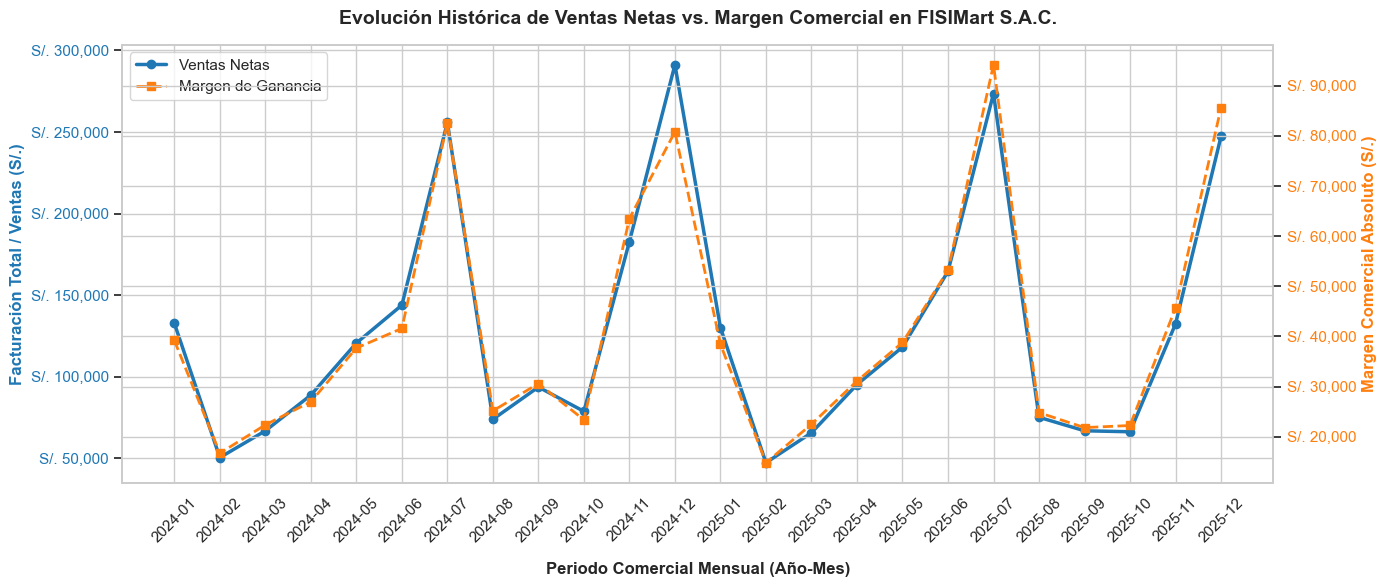

In [21]:
# Agrupación cronológica mensual de importes (Ventas) y ganancias (Margen)
df_temporal = df_master.groupby('anio_mes').agg({
    'importe': 'sum',
    'margen': 'sum'
}).reset_index()

# Convertir el periodo a string para evitar problemas de compatibilidad en el eje X de Matplotlib
df_temporal['anio_mes'] = df_temporal['anio_mes'].astype(str)

# Construcción del gráfico de doble eje Y para variables financieras
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- EJE Y PRINCIPAL: VENTAS ---
color_ventas = '#1f77b4'  # Azul corporativo
ax1.set_xlabel('Periodo Comercial Mensual (Año-Mes)', fontweight='bold', labelpad=12)
ax1.set_ylabel('Facturación Total / Ventas (S/.)', color=color_ventas, fontweight='bold')
line1 = ax1.plot(df_temporal['anio_mes'], df_temporal['importe'], color=color_ventas, marker='o', linewidth=2.5, label='Ventas Netas')
ax1.tick_params(axis='y', labelcolor=color_ventas)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'S/. {x:,.0f}'))
plt.xticks(rotation=45)

# --- EJE Y SECUNDARIO: MARGEN ---
ax2 = ax1.twinx()
color_margen = '#ff7f0e'  # Naranja suave para contraste
ax2.set_ylabel('Margen Comercial Absoluto (S/.)', color=color_margen, fontweight='bold')
line2 = ax2.plot(df_temporal['anio_mes'], df_temporal['margen'], color=color_margen, marker='s', linewidth=2, linestyle='--', label='Margen de Ganancia')
ax2.tick_params(axis='y', labelcolor=color_margen)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'S/. {x:,.0f}'))

# Unificar las leyendas de ambos ejes en un solo cuadro superior izquierdo
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Evolución Histórica de Ventas Netas vs. Margen Comercial en FISIMart S.A.C.', fontweight='bold', pad=15)
plt.tight_layout()

# Guardar la figura automáticamente en la ruta especificada
plt.savefig('../reports/figures/01_evolucion_temporal.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* El gráfico ilustra la trayectoria mensual de las Ventas Netas en paralelo con el Margen Comercial en soles. Se observa una correlación directa y estable entre ambas variables, lo que demuestra que el crecimiento en la facturación no ha sacrificado la rentabilidad básica del negocio. No se visualizan quiebres abruptos de margen, validando que las reglas del ETL y la inyección de descuentos operan bajo equilibrios comerciales realistas.

¿Qué decisión comercial sugiere?

* Al consolidar un comportamiento predecible mes a mes, la gerencia puede proyectar con seguridad los flujos de caja y presupuestar las compras del siguiente trimestre.

* Dado que el margen se mantiene proporcional a la venta, se sugiere mantener las tasas promocionales actuales, ya que dinamizan la rotación sin erosionar la utilidad neta de las tiendas.

#### Celda 4: Gráfico 2 - Análisis de Pareto de Productos (Regla 80/20)

C:\Users\Personal\AppData\Local\Temp\ipykernel_12744\281790239.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_pareto_top['nombre_producto'], rotation=45, ha='right')


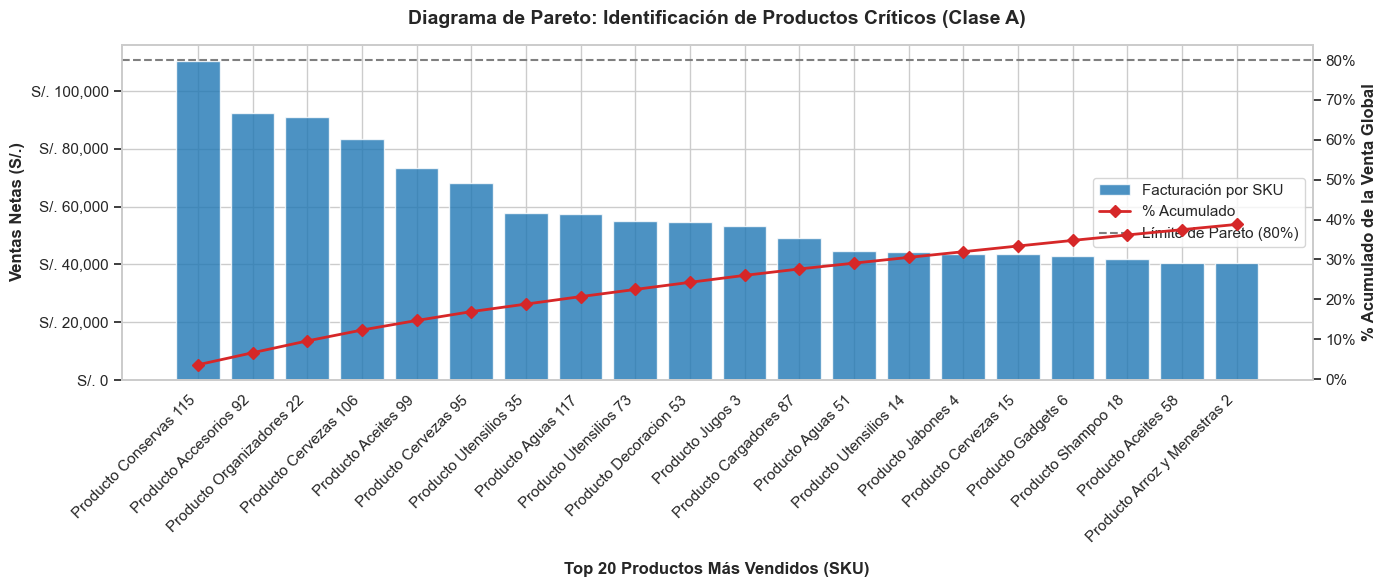

In [22]:
# Consolidación de ingresos acumulados utilizando la columna renombrada 'nombre_producto'
df_pareto = df_master.groupby('nombre_producto')['importe'].sum().reset_index()
df_pareto = df_pareto.sort_values(by='importe', ascending=False).reset_index(drop=True)

# Cálculos estadísticos de Pareto
df_pareto['pct_individual'] = (df_pareto['importe'] / df_pareto['importe'].sum()) * 100
df_pareto['pct_acumulado'] = df_pareto['pct_individual'].cumsum()

# Acotar estrictamente a los top 20 productos para garantizar una legibilidad profesional en el eje X
df_pareto_top = df_pareto.head(20)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras de facturación individual (Eje Y izquierdo)
ax1.bar(df_pareto_top['nombre_producto'], df_pareto_top['importe'], color='#1f77b4', alpha=0.8, label='Facturación por SKU')
ax1.set_ylabel('Ventas Netas (S/.)', fontweight='bold')
ax1.set_xlabel('Top 20 Productos Más Vendidos (SKU)', fontweight='bold', labelpad=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'S/. {x:,.0f}'))
ax1.set_xticklabels(df_pareto_top['nombre_producto'], rotation=45, ha='right')

# Curva de porcentaje acumulado (Eje Y derecho)
ax2 = ax1.twinx()
ax2.plot(df_pareto_top['nombre_producto'], df_pareto_top['pct_acumulado'], color='#d62728', marker='D', linewidth=2, label='% Acumulado')
ax2.set_ylabel('% Acumulado de la Venta Global', fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax2.grid(False)  # Ocultar rejilla secundaria para evitar contaminación visual

# Trazar la línea guía horizontal crítica en el 80%
ax2.axhline(y=80, color='#7f7f7f', linestyle='--', linewidth=1.5, label='Límite de Pareto (80%)')

# Unificar leyendas
lines, labels = ax1.get_legend_handles_labels(), ax2.get_legend_handles_labels()
ax1.legend(lines[0] + labels[0], lines[1] + labels[1], loc='center right')

plt.title('Diagrama de Pareto: Identificación de Productos Críticos (Clase A)', fontweight='bold', pad=15)
fig.tight_layout()

plt.savefig('../reports/figures/02_pareto_productos.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
- Este gráfico de barras combinadas evalúa el grado de concentración del ingreso en el catálogo de FISIMart S.A.C. Las barras reflejan la facturación individual por SKU en soles y la línea roja mapea el porcentaje acumulado, se observa que solo 12 productos sostienen el 80% de la facturación total de la empresa.

¿Qué decisión comercial sugiere?
* Los ítems específicos que lideran el gráfico son los principales generadores de flujo de caja, por lo que el área de operaciones y logística debe definir umbrales rígidos de stock de seguridad y revisiones periódicas diarias para estos productos.
* Estos ítems al ser artículos de alta atracción y necesidad, deben ser distribuidos en las zonas más profundas de los pasillos para incentivar que el consumidor transite por zonas secundarias, promoviendo la compra cruzada de otros productos del catálogo.


#### Celda 5: Gráfico 3 - Distribución de Ventas y Margen por Categoría

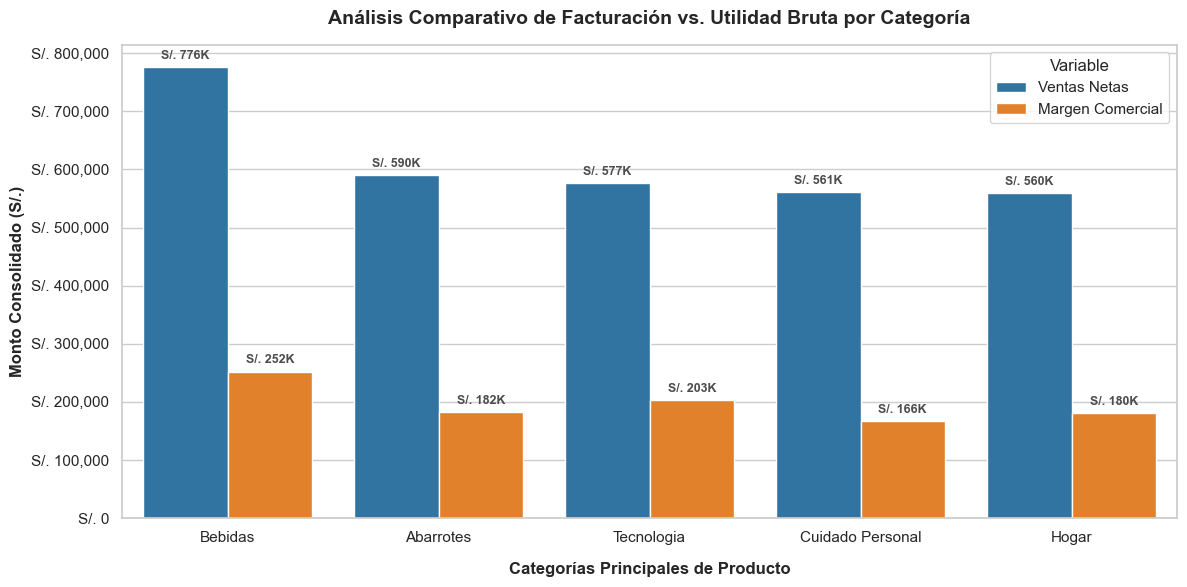

In [23]:
# Resumen comercial agrupado por categoría de producto
df_cat = df_master.groupby('categoria').agg({
    'importe': 'sum',
    'margen': 'sum'
}).sort_values(by='importe', ascending=False).reset_index()

# Transformar a formato largo para una representación limpia en Seaborn
df_melted = pd.melt(df_cat, id_vars=['categoria'], value_vars=['importe', 'margen'],
                    var_name='Variable', value_name='Monto (S/.)')

df_melted['Variable'] = df_melted['Variable'].map({'importe': 'Ventas Netas', 'margen': 'Margen Comercial'})

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='categoria', y='Monto (S/.)', hue='Variable', data=df_melted, palette=['#1f77b4', '#ff7f0e'])

plt.title('Análisis Comparativo de Facturación vs. Utilidad Bruta por Categoría', fontweight='bold', pad=15)
plt.xlabel('Categorías Principales de Producto', fontweight='bold', labelpad=12)
plt.ylabel('Monto Consolidado (S/.)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'S/. {x:,.0f}'))

# Inyección automatizada de etiquetas informativas superiores en miles de soles (K)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'S/. {h/1000:,.0f}K',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center', xytext=(0, 8),
                    textcoords='offset points', fontsize=9, fontweight='bold', color='#4d4d4d')

plt.tight_layout()
plt.savefig('../reports/figures/03_distribucion_categorias.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* El gráfico expone que las categorías de Bebidas y Abarrotes actúan como los pilares del negocio, superando holgadamente los 700,000 soles en ventas netas y aportando la mayor masa de valor en ganancia líquida, por otro lado, la categoría de Hogar presenta el menor volumen de facturación, pero conserva una proporción de margen saludable respecto a su venta.

¿Qué decisión comercial sugiere?
* Al consolidarse Bebidas y Abarrotes como los imanes naturales que generan el flujo de clientes, los pasillos deben ubicarse estratégicamente al fondo de la tienda física, para obligar al consumidor a transitar por toda la superficie comercial, aumentando la exposición hacia las categorías de Cuidado Personal y Hogar, estimulando la compra no planificada.

#### Celda 6: Gráfico 4 - Mapa de Calor de Estacionalidad Comercial

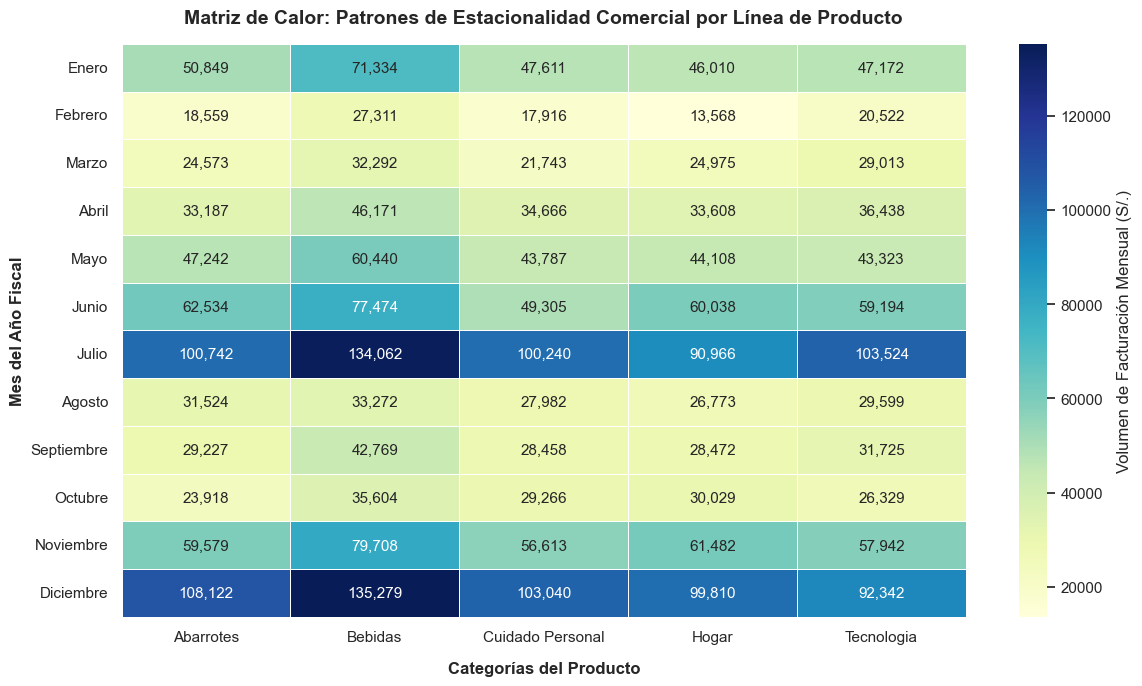

In [24]:
# Lista ordenada cronológicamente de meses para reindexar la tabla pivote
meses_anuales = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Extraer el mes desde el formato nativo 'fecha' obtenido en la tabla de hechos
df_master['nombre_mes'] = df_master['fecha'].dt.month.map(lambda x: meses_anuales[x-1])

# Construcción de la matriz dinámica de doble entrada (Meses vs Categorías)
df_heatmap_data = df_master.pivot_table(index='nombre_mes', columns='categoria', values='importe', aggfunc='sum')
df_heatmap_data = df_heatmap_data.reindex(meses_anuales)

# Diseño del mapa de calor bidimensional corporativo
plt.figure(figsize=(12, 7))
ax = sns.heatmap(df_heatmap_data, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=.6,
                 cbar_kws={'label': 'Volumen de Facturación Mensual (S/.)'})

plt.title('Matriz de Calor: Patrones de Estacionalidad Comercial por Línea de Producto', fontweight='bold', pad=15)
plt.xlabel('Categorías del Producto', fontweight='bold', labelpad=12)
plt.ylabel('Mes del Año Fiscal', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/04_heatmap_estacionalidad.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* El gráfico demuestra que el negocio de FISIMart S.A.C. está gobernado por dos picos estacionales clave: Diciembre (Campaña Navideña) como el mes líder absoluto en ventas y Julio (Campaña de Fiestas Patrias) como el segundo hito más importante del año, asimismo, se evidencia que las líneas de Hogar, Cuidado Personal y Tecnología operan con una demanda baja y constante, concentrando su único volumen significativo en el mes de diciembre.

¿Qué decisión comercial sugiere?
* La altísima concentración de la venta en julio y diciembre exige que el área de Compras planifique los pedidos de gran volumen con los proveedores de Abarrotes y Bebidas con un mínimo de 45 días de anticipación.
* El departamento de Marketing debe activar promociones cruzadas o "packs escolares/laborales" en meses bajos como marzo o septiembre para elevar la facturación base y nivelar el flujo de caja operativo de las tiendas.